## dockq score 비교 

=== 상위 5개 (개선됨) ===
8f5i_X_Y_A_42th_sample_0: 0.1420 (My: 0.743, KKH: 0.601)
8c7m_C_D_B_97th_sample_0: 0.1245 (My: 0.882, KKH: 0.758)
7yru_H_L_A_31th_sample_0: 0.1160 (My: 0.808, KKH: 0.692)
8c7m_C_D_B_42th_sample_0: 0.1023 (My: 0.762, KKH: 0.659)
8c7m_C_D_B_92th_sample_0: 0.0936 (My: 0.822, KKH: 0.728)

=== 하위 5개 (하락함) ===
7u8g_D_E_A_59th_sample_0: -0.0838 (My: 0.488, KKH: 0.572)
8f6o_A_B_C_45th_sample_0: -0.0870 (My: 0.663, KKH: 0.750)
8hs2_B_C_R_9th_sample_0: -0.0913 (My: 0.749, KKH: 0.840)
8f6o_A_B_C_1th_sample_0: -0.1017 (My: 0.607, KKH: 0.709)
8hs2_B_C_R_8th_sample_0: -0.1267 (My: 0.641, KKH: 0.768)


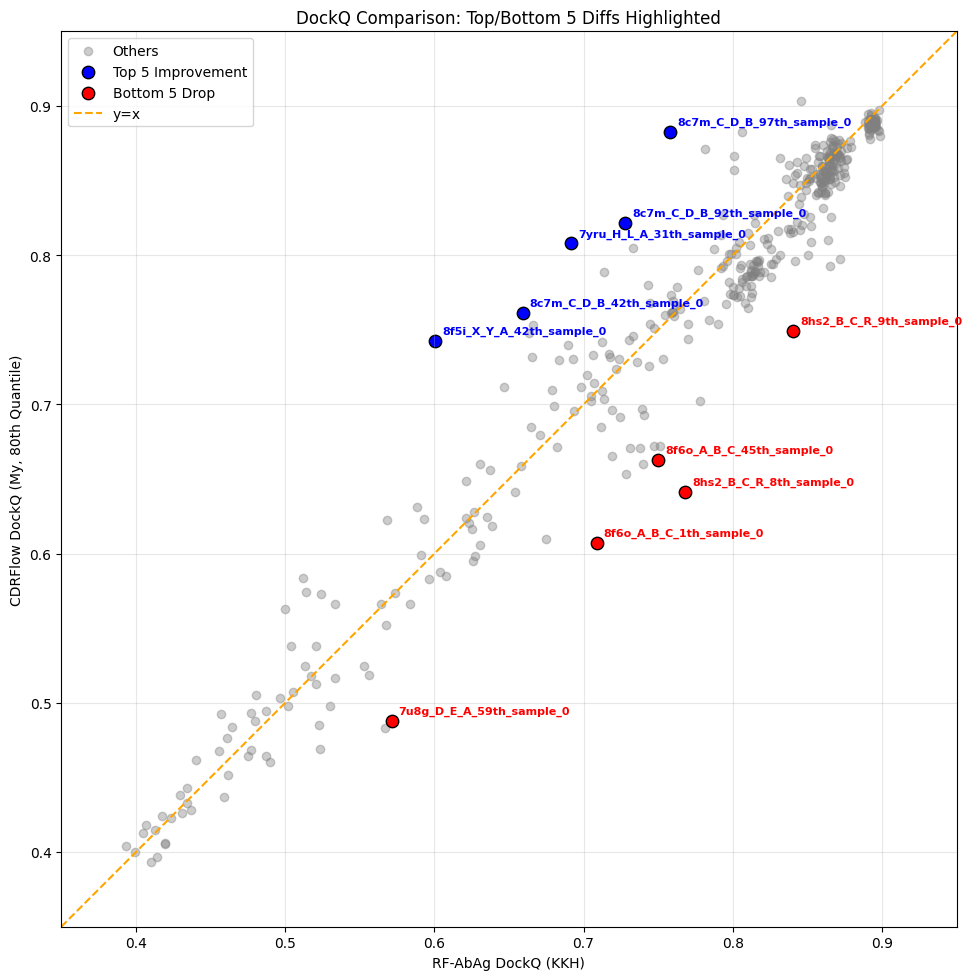

In [10]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# 경로 설정
kkh_dir = '/home/psh/BioBetter/kkh_benchmark/chothia'
my_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/kkh_wo_perturb'

results = []

# 데이터 수집
for pdb_sample_id in os.listdir(my_dir):
    if 'config' in pdb_sample_id: continue
    
    pdb_id = '_'.join(pdb_sample_id.split('_')[:4])
    sample_id = '_'.join(pdb_sample_id.split('_')[4:])
    kkh_dockq_file = os.path.join(kkh_dir, pdb_id, sample_id + '.pdb_dockq.json')
    
    if not os.path.exists(kkh_dockq_file): continue
    
    with open(kkh_dockq_file, 'r') as f:
        kkh_val = json.load(f)['GlobalDockQ']
    
    sample_dockqs_temp = []
    # 하위 디렉토리 탐색 (subsample)
    sub_dir = os.path.join(my_dir, pdb_sample_id)
    if not os.path.isdir(sub_dir): continue

    for subsample in os.listdir(sub_dir):
        my_dockq_file = os.path.join(sub_dir, subsample, 'dockq.json')
        if os.path.exists(my_dockq_file):
            with open(my_dockq_file, 'r') as f:
                sample_dockqs_temp.append(json.load(f)['GlobalDockQ'])
    
    if len(sample_dockqs_temp) > 0:
        my_val = np.quantile(sample_dockqs_temp, 0.8)
        diff = my_val - kkh_val
        results.append({
            'id': pdb_sample_id,
            'kkh': kkh_val,
            'my': my_val,
            'diff': diff
        })

# 차이값 기준 정렬
results.sort(key=lambda x: x['diff'], reverse=True)
top_5 = results[:5]
bottom_5 = results[-5:]

# 콘솔 출력
print("=== 상위 5개 (개선됨) ===")
for r in top_5: print(f"{r['id']}: {r['diff']:.4f} (My: {r['my']:.3f}, KKH: {r['kkh']:.3f})")

print("\n=== 하위 5개 (하락함) ===")
for r in bottom_5: print(f"{r['id']}: {r['diff']:.4f} (My: {r['my']:.3f}, KKH: {r['kkh']:.3f})")

# 시각화
plt.figure(figsize=(10, 10))
kkh_vals = [r['kkh'] for r in results]
my_vals = [r['my'] for r in results]

plt.scatter(kkh_vals, my_vals, alpha=0.4, c='gray', label='Others')

# 상/하위 5개 강조 및 텍스트 표시
def plot_annotated(subset, color, label):
    xs = [r['kkh'] for r in subset]
    ys = [r['my'] for r in subset]
    plt.scatter(xs, ys, c=color, edgecolors='black', s=80, label=label)
    for r in subset:
        plt.annotate(r['id'], (r['kkh'], r['my']), 
                     xytext=(5, 5), textcoords='offset points', 
                     fontsize=8, fontweight='bold', color=color)

plot_annotated(top_5, 'blue', 'Top 5 Improvement')
plot_annotated(bottom_5, 'red', 'Bottom 5 Drop')

# y = x 라인 및 설정
plt.plot([0.35, 0.95], [0.35, 0.95], linestyle='--', c='orange', label='y=x')
plt.xlim(0.35, 0.95)
plt.ylim(0.35, 0.95)
plt.gca().set_aspect('equal')

plt.xlabel("RF-AbAg DockQ (KKH)")
plt.ylabel("CDRFlow DockQ (My, 80th Quantile)")
plt.title("DockQ Comparison: Top/Bottom 5 Diffs Highlighted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

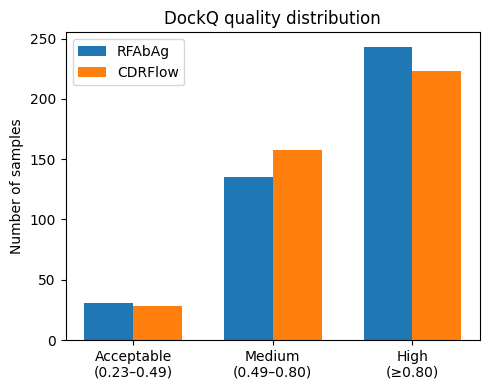

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays
kkh = np.array(kkh_dockqs)
my = np.array(my_dockqs)

# DockQ thresholds
bins = [(0.23, 0.49), (0.49, 0.80), (0.80, np.inf)]
labels = [
    "Acceptable\n(0.23–0.49)",
    "Medium\n(0.49–0.80)",
    "High\n(≥0.80)"
]

def count_by_bins(values, bins):
    return [
        np.sum((values >= low) & (values < high))
        for low, high in bins
    ]

kkh_counts = count_by_bins(kkh, bins)
my_counts = count_by_bins(my, bins)

# Bar positions
x = np.arange(len(labels))
width = 0.35

# Plot
plt.figure(figsize=(5, 4))
plt.bar(x - width/2, kkh_counts, width, label="RFAbAg")
plt.bar(x + width/2, my_counts, width, label="CDRFlow")

plt.xticks(x, labels)
plt.ylabel("Number of samples")
plt.title("DockQ quality distribution")
plt.legend()
plt.tight_layout()
plt.show()
